# RF + DiCE + SHAP + análisis de casos sin contrafactual

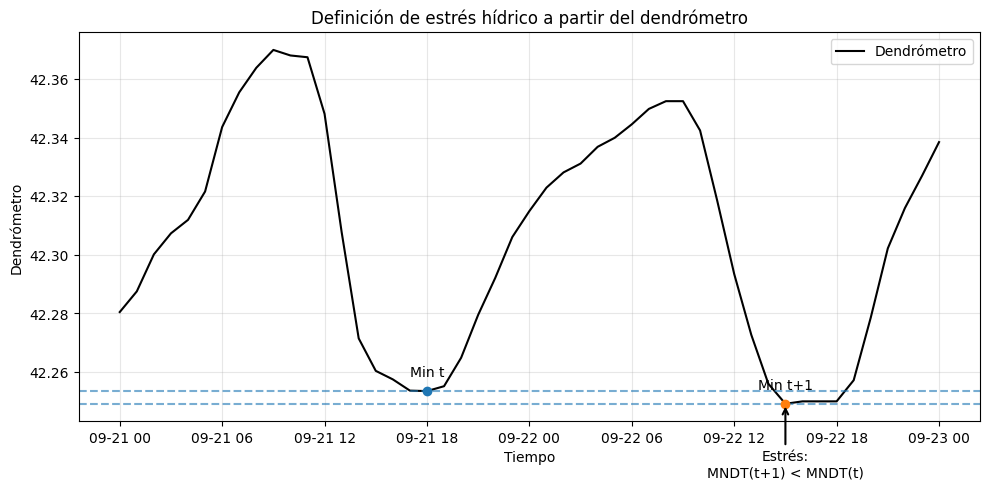

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CARGA
# =========================
df = pd.read_csv("data_hourly_agg.csv")
df["instante"] = pd.to_datetime(df["instante"])

# =========================
# SELECCIÓN (tu caso)
# =========================
inst = pd.to_datetime("2021-09-22")

start = inst - pd.Timedelta(days=1)
end = inst + pd.Timedelta(days=1)

df_plot = df[(df["instante"] >= start) & (df["instante"] <= end)].copy()
df_plot["date"] = df_plot["instante"].dt.date

# =========================
# MÍNIMOS
# =========================
mins = df_plot.groupby("date")["dendrometro_mean"].min()

days = list(mins.index[:2])

points = []
for d in days:
    sub = df_plot[df_plot["date"] == d]
    idx = sub["dendrometro_mean"].idxmin()
    points.append((df_plot.loc[idx, "instante"], df_plot.loc[idx, "dendrometro_mean"]))

# =========================
# PLOT
# =========================
plt.figure(figsize=(10,5))

plt.plot(df_plot["instante"], df_plot["dendrometro_mean"], color="black", label="Dendrómetro")

# marcar mínimos
for (x,y), label in zip(points, ["Min t", "Min t+1"]):
    plt.scatter(x, y, zorder=3)
    plt.text(x, y+0.005, label, ha='center', fontsize=10)

# líneas horizontales
plt.axhline(points[0][1], linestyle="--", alpha=0.6)
plt.axhline(points[1][1], linestyle="--", alpha=0.6)

# =========================
# ANOTACIÓN (BIEN PUESTA)
# =========================
x_arrow = points[1][0]
y_arrow = points[1][1]

plt.annotate("Estrés:\nMNDT(t+1) < MNDT(t)",
             xy=(x_arrow, y_arrow),
             xytext=(x_arrow, y_arrow - 0.025),
             arrowprops=dict(arrowstyle="->", lw=1.5),
             ha='center',
             fontsize=10)

# =========================
# ESTÉTICA
# =========================
plt.title("Definición de estrés hídrico a partir del dendrómetro")
plt.xlabel("Tiempo")
plt.ylabel("Dendrómetro")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("figura_estres_final.png", dpi=300)
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import dice_ml
from dice_ml import Dice
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

# =========================
# CONFIGURACIÓN
# =========================
DATA_PATH = "dataset_learning_24h.csv"

# CAMBIA ESTA RUTA SI TU RF ESTÁ EN OTRA CARPETA
MODEL_PATH = "model_Hybrid_SMOTEplusCost_RF_final.pkl"

# threshold operativo del RF
THRESHOLD = 0.5

# columnas Set_Type que quieres usar para el análisis interpretativo
SET_TYPES_ANALYSIS = ["Train_CV", "Test_Temporal"]

# variables del modelo RF
FEATURES = [
    "radiacion_sum_t0",
    "HS30_min_t+1"
]

TARGET = "Target_Class"

# variables que podrá modificar DiCE
FEATURES_TO_VARY_DICE = ["HS30_min_t+1"]

# rango máximo de HS30
HS30_MAX = 1.0

# nombre de la columna fecha
DATE_COL = "instante_t+1"

print("Configuración cargada.")
print("Modelo:", MODEL_PATH)
print("Threshold:", THRESHOLD)
print("Features:", FEATURES)


Configuración cargada.
Modelo: model_Hybrid_SMOTEplusCost_RF_final.pkl
Threshold: 0.5
Features: ['radiacion_sum_t0', 'HS30_min_t+1']


C:\Users\Iratxe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# =========================
# CARGA DE DATOS Y MODELO
# =========================
df = pd.read_csv(DATA_PATH)
pipe = joblib.load(MODEL_PATH)

print("Shape dataset:", df.shape)
print(df["Set_Type"].value_counts(dropna=False))

missing_cols = [c for c in FEATURES + [TARGET, "Set_Type"] if c not in df.columns]
if len(missing_cols) > 0:
    raise ValueError(f"Faltan columnas en el CSV: {missing_cols}")

print("Carga correcta.")


Shape dataset: (131, 38)
Set_Type
Train_CV         93
Test_Temporal    24
Test_Spatial     14
Name: count, dtype: int64
Carga correcta.


In [5]:
# =========================
# DATASET DE ANÁLISIS
# =========================
df_all = df[df["Set_Type"].isin(SET_TYPES_ANALYSIS)].copy()

X_all = df_all[FEATURES].copy()
y_all = df_all[TARGET].copy()

y_prob = pipe.predict_proba(X_all)[:, 1]
y_pred = (y_prob >= THRESHOLD).astype(int)

df_all["pred_prob_stress"] = y_prob
df_all["pred_class"] = y_pred

tn, fp, fn, tp = confusion_matrix(y_all, y_pred).ravel()

print("=== RESULTADOS GENERALES ===")
print("Total casos:", len(df_all))
print("Predichos como estrés:", int((df_all["pred_class"] == 1).sum()))
print(f"TP: {tp}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TN: {tn}")

print("\nMétricas:")
print("Accuracy :", round(accuracy_score(y_all, y_pred), 3))
print("Recall   :", round(recall_score(y_all, y_pred), 3))
print("Precision:", round(precision_score(y_all, y_pred, zero_division=0), 3))
print("F1       :", round(f1_score(y_all, y_pred, zero_division=0), 3))


=== RESULTADOS GENERALES ===
Total casos: 117
Predichos como estrés: 52
TP: 29
FP: 23
FN: 0
TN: 65

Métricas:
Accuracy : 0.803
Recall   : 1.0
Precision: 0.558
F1       : 0.716


In [6]:
# =========================
# CASOS DE ESTRÉS REALES Y DETECTADOS
# =========================
real_stress = df_all[df_all[TARGET] == 1].copy()

stress_cases = df_all[
    (df_all[TARGET] == 1) &
    (df_all["pred_class"] == 1)
].copy().reset_index(drop=True)

stress_not_detected = df_all[
    (df_all[TARGET] == 1) &
    (df_all["pred_class"] == 0)
].copy()

print("=== CASOS DE ESTRÉS ===")
print("Reales:", len(real_stress))
print("Detectados:", len(stress_cases))
print("No detectados:", len(stress_not_detected))

if len(stress_not_detected) > 0:
    cols_show = [c for c in [DATE_COL, "Set_Type", TARGET, "pred_prob_stress"] if c in stress_not_detected.columns]
    display(stress_not_detected[cols_show].head())


=== CASOS DE ESTRÉS ===
Reales: 29
Detectados: 29
No detectados: 0


In [7]:
# =========================
# OBJETO DiCE
# =========================
data_dice = dice_ml.Data(
    dataframe=df_all[FEATURES + [TARGET]],
    continuous_features=FEATURES,
    outcome_name=TARGET
)

model_dice = dice_ml.Model(
    model=pipe,
    backend="sklearn"
)

exp = Dice(data_dice, model_dice)

print("Objeto DiCE creado.")


Objeto DiCE creado.


In [8]:
# =========================
# PRUEBA CON UN SOLO CASO
# =========================
if len(stress_cases) == 0:
    print("No hay casos de estrés detectados para analizar.")
else:
    query_instance = stress_cases[FEATURES].iloc[[0]].copy()
    real_hs30 = query_instance["HS30_min_t+1"].iloc[0]
    lower_bound = min(real_hs30 + 0.001, HS30_MAX)

    try:
        dice_exp = exp.generate_counterfactuals(
            query_instance,
            total_CFs=1,
            desired_class=0,
            features_to_vary=FEATURES_TO_VARY_DICE,
            permitted_range={"HS30_min_t+1": [lower_bound, HS30_MAX]}
        )
        cf_test = dice_exp.cf_examples_list[0].final_cfs_df
        if cf_test is None or cf_test.empty:
            print("No se encontró contrafactual para el primer caso.")
        else:
            display(cf_test)
    except Exception as e:
        print("Error en la prueba individual:", e)


100%|██████████| 1/1 [00:00<00:00, 30.45it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
Error en la prueba individual: No counterfactuals found for any of the query points! Kindly check your configuration.


In [9]:
# =========================
# GENERAR 1 CONTRAFACTUAL POR CASO
# =========================
all_cf_rows = []
cases_without_cf = []
cases_with_errors = []

for i in range(len(stress_cases)):
    query_instance = stress_cases[FEATURES].iloc[[i]].copy()
    real_hs30 = query_instance["HS30_min_t+1"].iloc[0]
    lower_bound = min(real_hs30 + 0.001, HS30_MAX)

    if lower_bound >= HS30_MAX:
        cases_without_cf.append(i)
        continue

    try:
        dice_exp = exp.generate_counterfactuals(
            query_instance,
            total_CFs=1,
            desired_class=0,
            features_to_vary=FEATURES_TO_VARY_DICE,
            permitted_range={"HS30_min_t+1": [lower_bound, HS30_MAX]}
        )

        cf_df = dice_exp.cf_examples_list[0].final_cfs_df

        if cf_df is None or cf_df.empty:
            cases_without_cf.append(i)
            continue

        cf_df = cf_df.copy()
        cf_df["case_index"] = i

        for col in FEATURES:
            cf_df[f"original_{col}"] = query_instance.iloc[0][col]

        if DATE_COL in stress_cases.columns:
            cf_df[DATE_COL] = stress_cases.iloc[i][DATE_COL]

        if "Set_Type" in stress_cases.columns:
            cf_df["Set_Type"] = stress_cases.iloc[i]["Set_Type"]

        if "pred_prob_stress" in stress_cases.columns:
            cf_df["original_pred_prob_stress"] = stress_cases.iloc[i]["pred_prob_stress"]

        cf_hs30 = cf_df["HS30_min_t+1"].iloc[0]
        if (cf_hs30 > real_hs30) and (cf_hs30 <= HS30_MAX):
            all_cf_rows.append(cf_df)
        else:
            cases_without_cf.append(i)

    except Exception as e:
        cases_without_cf.append(i)
        cases_with_errors.append({"case_index": i, "error": str(e)})
        continue

print("=== RESUMEN DICE ===")
print("Casos de estrés detectados:", len(stress_cases))
print("Casos con contrafactual:", len(all_cf_rows))
print("Casos sin contrafactual:", len(cases_without_cf))
print("Casos con error controlado:", len(cases_with_errors))


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 29.28it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|██████████| 1/1 [00:00<00:00, 33.05it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


...

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|██████████| 1/1 [00:00<00:00, 42.59it/s]


No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec


100%|██████████| 1/1 [00:00<00:00, 12.94it/s]

=== RESUMEN DICE ===
Casos de estrés detectados: 29
Casos con contrafactual: 21
Casos sin contrafactual: 8
Casos con error controlado: 8


In [10]:
# =========================
# GUARDAR RESULTADOS DICE
# =========================
if len(all_cf_rows) > 0:
    cf_results = pd.concat(all_cf_rows, ignore_index=True)
    cf_results.to_csv("rf_dice_counterfactuals.csv", index=False)
    print("Guardado: rf_dice_counterfactuals.csv")
    display(cf_results.head())
else:
    cf_results = pd.DataFrame()
    print("No se generó ningún contrafactual válido.")

cases_no_cf_df = stress_cases.iloc[cases_without_cf].copy() if len(cases_without_cf) > 0 else pd.DataFrame()
cases_no_cf_df.to_csv("rf_cases_without_cf.csv", index=False)
print("Guardado: rf_cases_without_cf.csv")

if len(cases_with_errors) > 0:
    pd.DataFrame(cases_with_errors).to_csv("rf_cases_with_dice_errors.csv", index=False)
    print("Guardado: rf_cases_with_dice_errors.csv")


Guardado: rf_dice_counterfactuals.csv


,radiacion_sum_t0,HS30_min_t+1,Target_Class,case_index,original_radiacion_sum_t0,original_HS30_min_t+1,instante_t+1,Set_Type,original_pred_prob_stress
0,3222.0,0.925828,0,4,3222.0,0.797069,2018-10-29,Train_CV,0.890331
1,7111.0,0.955204,0,6,7111.0,0.738180,2019-08-07,Train_CV,0.650427
2,3994.0,0.997323,0,8,3994.0,0.735565,2019-09-15,Train_CV,0.925485
3,3906.0,0.928106,0,9,3906.0,0.711295,2019-09-18,Train_CV,0.931265
4,3861.0,0.847660,0,10,3861.0,0.726288,2019-09-22,Train_CV,0.935527


Guardado: rf_cases_without_cf.csv
Guardado: rf_cases_with_dice_errors.csv


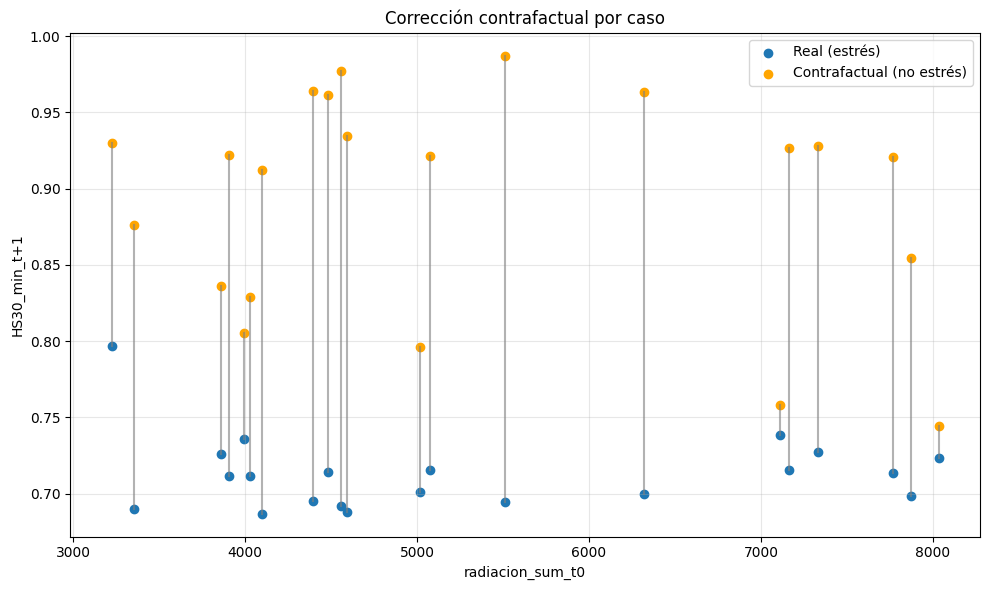

In [ ]:
# =========================
# CORRECCIÓN CONTRAFACTUAL 
# =========================
import matplotlib.pyplot as plt
import pandas as pd

df_cf = pd.read_csv("rf_dice_counterfactuals.csv")

plt.figure(figsize=(10,6))

for i in range(len(df_cf)):
    x = df_cf["original_radiacion_sum_t0"].iloc[i]

    y_real = df_cf["original_HS30_min_t+1"].iloc[i]
    y_cf = df_cf["HS30_min_t+1"].iloc[i]

    # punto real (azul)
    plt.scatter(x, y_real, color="tab:blue")

    # punto contrafactual (fucsia)
    plt.scatter(x, y_cf, color="orange")

    # línea de conexión (gris)
    plt.plot([x, x], [y_real, y_cf], color="gray", alpha=0.6)

# etiquetas
plt.xlabel("radiacion_sum_t0")
plt.ylabel("HS30_min_t+1")
plt.title("Corrección contrafactual por caso")

# leyenda bien hecha (importante)
plt.scatter([], [], color="tab:blue", label="Real (estrés)")
plt.scatter([], [], color="orange", label="Contrafactual (no estrés)")
plt.legend()

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [2]:
# =========================
# MÉTRICAS DEL CAMBIO CONTRAFACTUAL
# =========================

df_cf["incremento_HS30"] = (
    df_cf["HS30_min_t+1"] - df_cf["original_HS30_min_t+1"]
)

media_inc = df_cf["incremento_HS30"].mean()
sd_inc = df_cf["incremento_HS30"].std()
min_inc = df_cf["incremento_HS30"].min()
max_inc = df_cf["incremento_HS30"].max()
mediana_inc = df_cf["incremento_HS30"].median()

print("Incremento medio HS30:", round(media_inc, 4))
print("Desviación estándar:", round(sd_inc, 4))
print("Mediana:", round(mediana_inc, 4))
print("Incremento mínimo:", round(min_inc, 4))
print("Incremento máximo:", round(max_inc, 4))

Incremento medio HS30: 0.1798
Desviación estándar: 0.0823
Mediana: 0.2058
Incremento mínimo: 0.0199
Incremento máximo: 0.2929


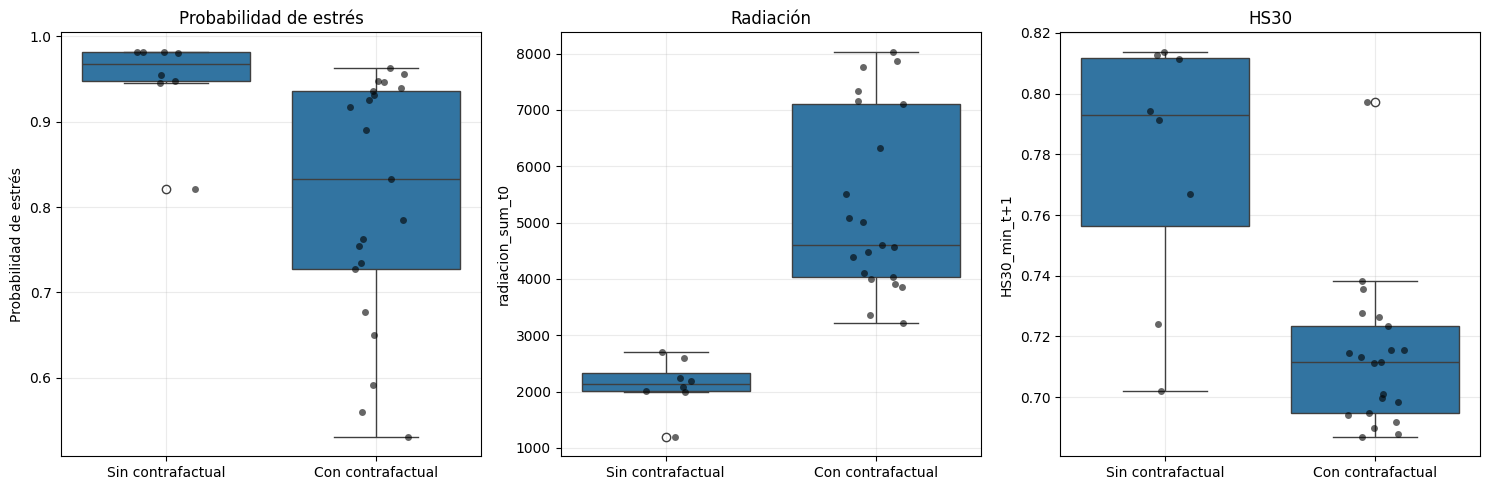

In [ ]:
# =========================
# BOXPLOTS CON VS SIN CONTRAFACTUAL
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# Si aún no lo tienes:
stress_cases_plot = stress_cases.copy()
stress_cases_plot["has_cf"] = 1
if len(cases_without_cf) > 0:
    stress_cases_plot.loc[cases_without_cf, "has_cf"] = 0

stress_cases_plot["grupo_cf"] = stress_cases_plot["has_cf"].map({
    0: "Sin contrafactual",
    1: "Con contrafactual"
})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

variables = ["pred_prob_stress", "radiacion_sum_t0", "HS30_min_t+1"]
titulos = [
    "Probabilidad de estrés",
    "Radiación",
    "HS30"
]
ylabels = [
    "Probabilidad de estrés",
    "radiacion_sum_t0",
    "HS30_min_t+1"
]

for ax, var, titulo, ylabel in zip(axes, variables, titulos, ylabels):
    sns.boxplot(
        data=stress_cases_plot,
        x="grupo_cf",
        y=var,
        ax=ax
    )
    sns.stripplot(
        data=stress_cases_plot,
        x="grupo_cf",
        y=var,
        ax=ax,
        color="black",
        alpha=0.6,
        jitter=0.15
    )
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("boxplots_cf_resumen.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# =========================
# CARGAR DATOS HORARIOS
# =========================
df_hourly = pd.read_csv("data_hourly_agg.csv")
df_hourly["instante"] = pd.to_datetime(df_hourly["instante"])

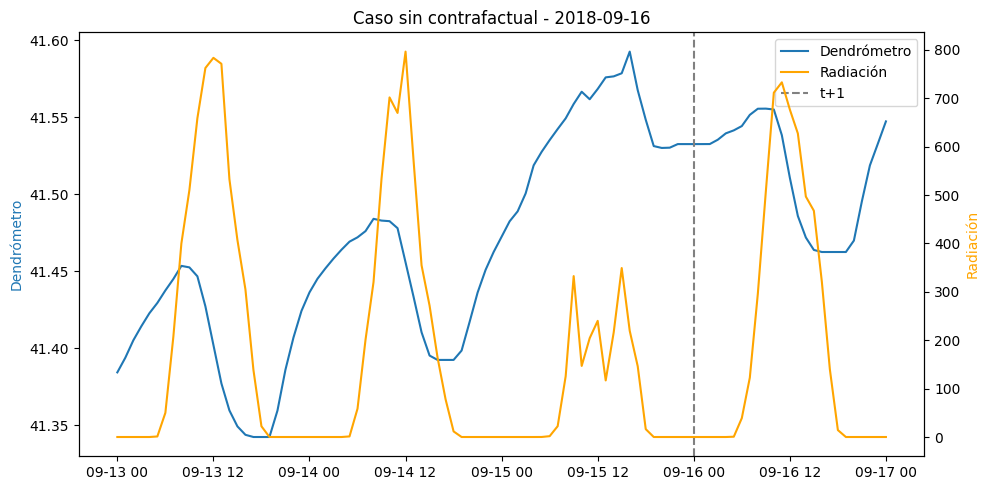

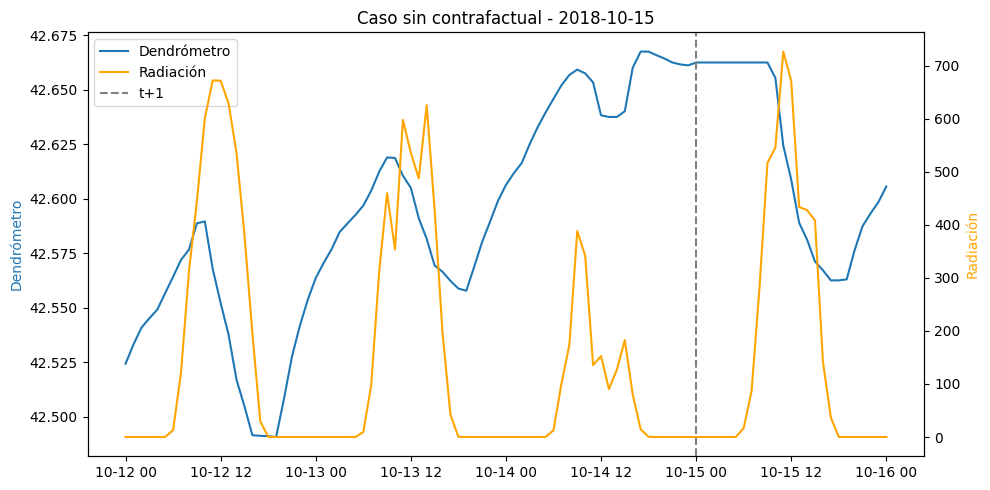

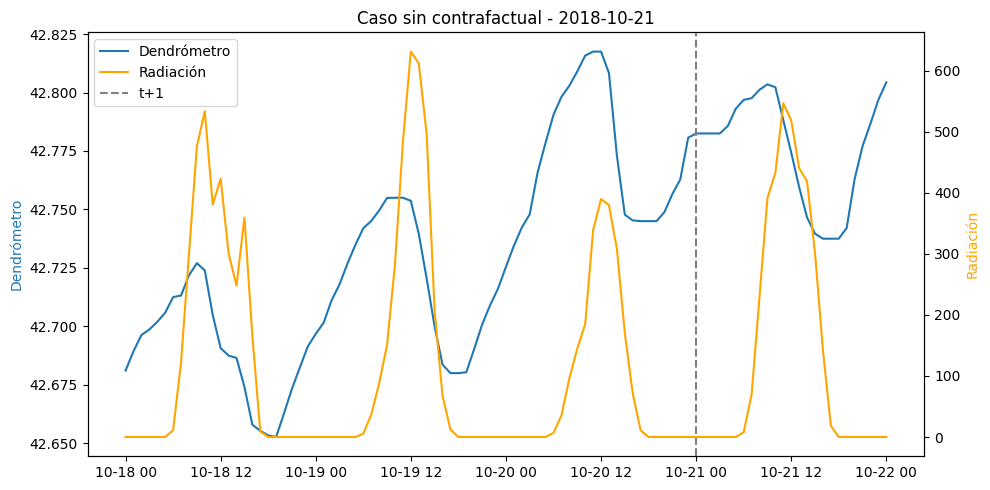

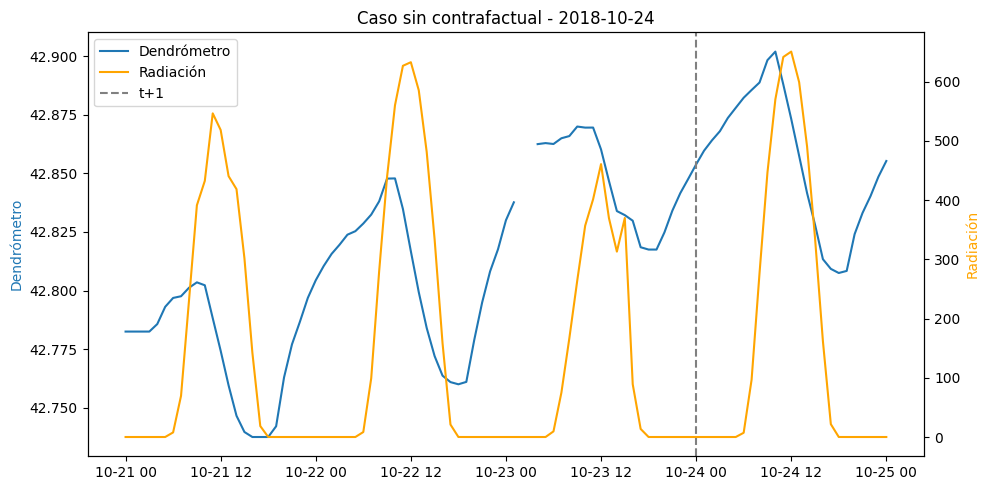

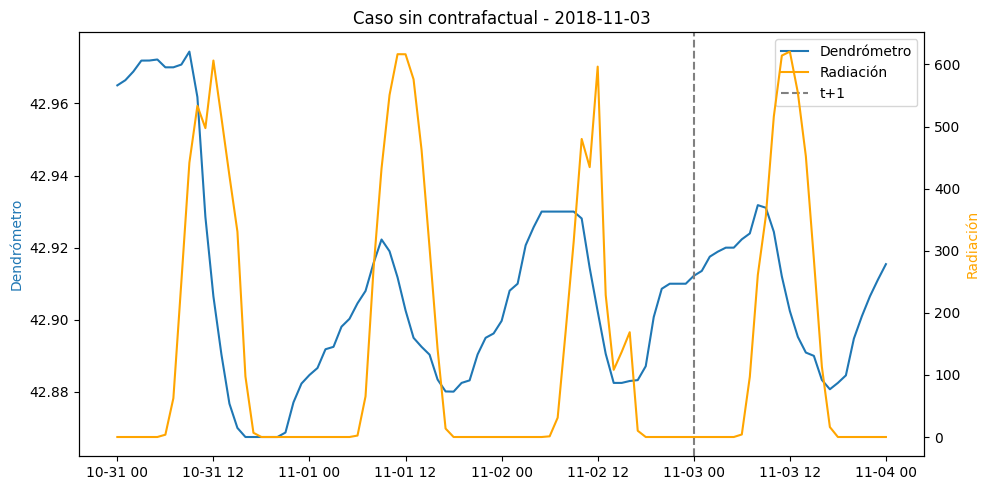

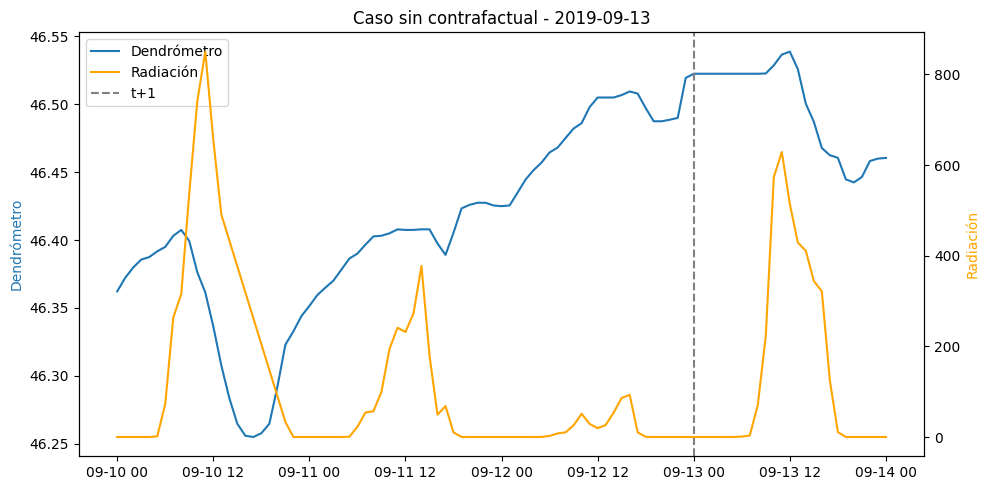

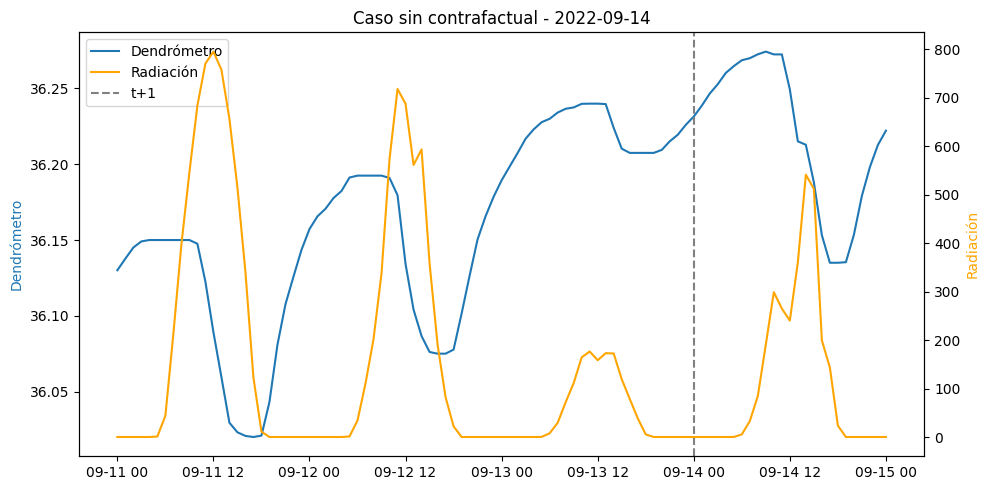

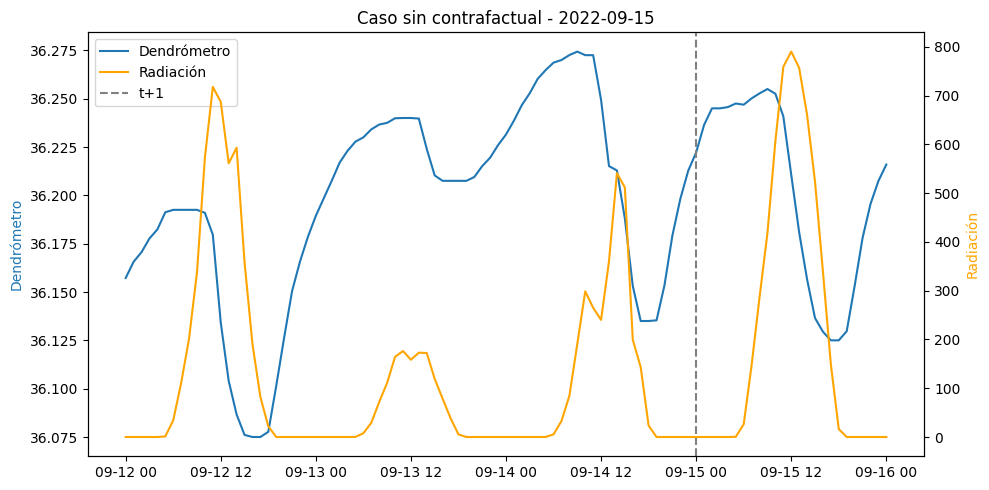

In [ ]:
# =========================
# PLOT CASOS SIN CF
# =========================

cases = cases_no_cf_df["instante_t+1"].tolist()
for inst in cases:
    
    inst = pd.to_datetime(inst)

    start = inst - pd.Timedelta(days=3)
    end = inst + pd.Timedelta(days=1)

    df_case = df_hourly[
        (df_hourly["instante"] >= start) &
        (df_hourly["instante"] <= end)
    ].copy()

    # =========================
    # PLOT
    # =========================
    fig, ax1 = plt.subplots(figsize=(10,5))

    # dendrómetro (azul)
    line1, = ax1.plot(
        df_case["instante"],
        df_case["dendrometro_mean"],
        color="tab:blue",
        label="Dendrómetro"
    )
    ax1.set_ylabel("Dendrómetro", color="tab:blue")

    # segunda escala
    ax2 = ax1.twinx()

    # radiación (fucsia)
    line2, = ax2.plot(
        df_case["instante"],
        df_case["radiacion_mean"],
        color="orange",
        label="Radiación"
    )
    ax2.set_ylabel("Radiación", color="orange")

    # línea t+1
    vline = ax1.axvline(inst, linestyle="--", color="gray", label="t+1")

    # leyenda combinada (clave)
    lines = [line1, line2, vline]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels)

    plt.title(f"Caso sin contrafactual - {inst.date()}")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [ ]:
# =========================
# PREPARAR SHAP
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Extraer scaler y modelo interno del pipeline
scaler = pipe.named_steps["scaler"]
rf_model = pipe.named_steps["classifier"]

# Casos reales de estrés detectados por el modelo
X_stress = stress_cases[FEATURES].copy()

# Escalado
X_stress_scaled = scaler.transform(X_stress)
X_stress_scaled = pd.DataFrame(
    X_stress_scaled,
    columns=FEATURES,
    index=X_stress.index
)

# Explainer
explainer = shap.TreeExplainer(rf_model)

# Calcular SHAP values
try:
    shap_values_stress = explainer.shap_values(X_stress_scaled)
except Exception:
    shap_values_stress = explainer(X_stress_scaled).values

shap_values_stress = np.array(shap_values_stress)

# Compatibilidad según versión de shap / sklearn
if shap_values_stress.ndim == 3:
    shap_values_stress = shap_values_stress[:, :, 1]

print("Shape SHAP global:", shap_values_stress.shape)

Shape SHAP global: (29, 2)


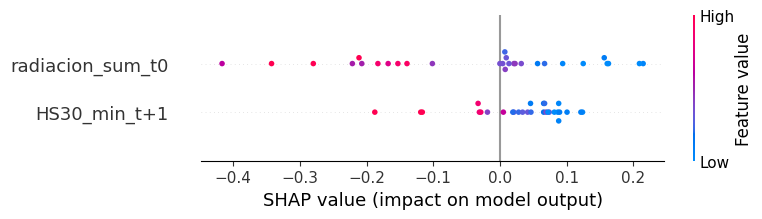

In [ ]:
# =========================
# SHAP GLOBAL
# =========================
if len(stress_cases) > 0:
    shap.summary_plot(
        shap_values_stress,
        X_stress_scaled,
        show=True
    )
else:
    print("No hay casos de estrés detectados para SHAP.")

In [ ]:
# =========================
# SEPARAR CASOS CON Y SIN CF
# =========================
if len(stress_cases) > 0:
    idx_without_cf = list(cases_without_cf)
    idx_with_cf = sorted(list(set(range(len(stress_cases))) - set(idx_without_cf)))

    X_with_cf = (
        X_stress.iloc[idx_with_cf].copy()
        if len(idx_with_cf) > 0
        else pd.DataFrame(columns=FEATURES)
    )
    X_without_cf = (
        X_stress.iloc[idx_without_cf].copy()
        if len(idx_without_cf) > 0
        else pd.DataFrame(columns=FEATURES)
    )

    print("Casos con CF:", len(X_with_cf))
    print("Casos sin CF:", len(X_without_cf))
else:
    print("No hay casos suficientes.")

Casos con CF: 21
Casos sin CF: 8


In [ ]:
# =========================
# SHAP CON CF Y SIN CF
# =========================
# Escalado
if len(X_with_cf) > 0:
    X_with_cf_scaled = pd.DataFrame(
        scaler.transform(X_with_cf),
        columns=FEATURES,
        index=X_with_cf.index
    )

    try:
        shap_values_with = explainer.shap_values(X_with_cf_scaled)
    except Exception:
        shap_values_with = explainer(X_with_cf_scaled).values

    shap_values_with = np.array(shap_values_with)
    if shap_values_with.ndim == 3:
        shap_values_with = shap_values_with[:, :, 1]
else:
    X_with_cf_scaled = pd.DataFrame(columns=FEATURES)
    shap_values_with = np.empty((0, len(FEATURES)))

if len(X_without_cf) > 0:
    X_without_cf_scaled = pd.DataFrame(
        scaler.transform(X_without_cf),
        columns=FEATURES,
        index=X_without_cf.index
    )

    try:
        shap_values_without = explainer.shap_values(X_without_cf_scaled)
    except Exception:
        shap_values_without = explainer(X_without_cf_scaled).values

    shap_values_without = np.array(shap_values_without)
    if shap_values_without.ndim == 3:
        shap_values_without = shap_values_without[:, :, 1]
else:
    X_without_cf_scaled = pd.DataFrame(columns=FEATURES)
    shap_values_without = np.empty((0, len(FEATURES)))

print("Shape SHAP con CF:", shap_values_with.shape)
print("Shape SHAP sin CF:", shap_values_without.shape)

Shape SHAP con CF: (21, 2)
Shape SHAP sin CF: (8, 2)


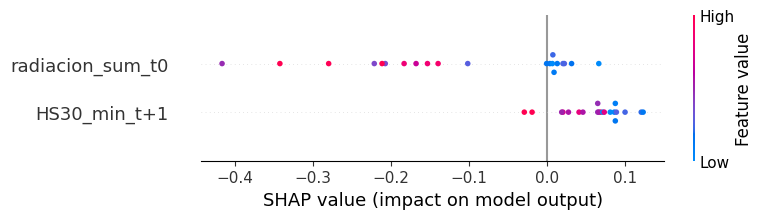

In [21]:
# %%
# =========================
# SHAP SOLO CASOS CON CF
# =========================
if len(X_with_cf) > 0:
    shap.summary_plot(
        shap_values_with,
        X_with_cf_scaled,
        show=True
    )
else:
    print("No hay casos con contrafactual.")

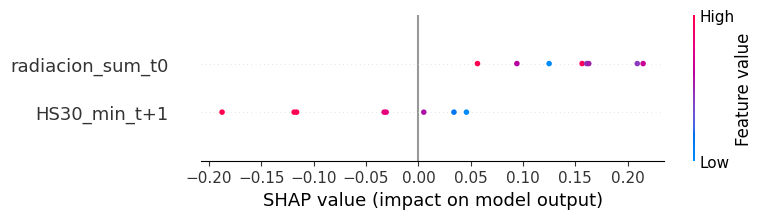

In [22]:
# %%
# =========================
# SHAP SOLO CASOS SIN CF
# =========================
if len(X_without_cf) > 0:
    shap.summary_plot(
        shap_values_without,
        X_without_cf_scaled,
        show=True
    )
else:
    print("No hay casos sin contrafactual.")

In [23]:
# %%
# =========================
# IMPORTANCIA SHAP MEDIA ABSOLUTA
# =========================
mean_with = (
    pd.DataFrame(shap_values_with, columns=FEATURES).abs().mean()
    if len(shap_values_with) > 0
    else pd.Series(dtype=float)
)

mean_without = (
    pd.DataFrame(shap_values_without, columns=FEATURES).abs().mean()
    if len(shap_values_without) > 0
    else pd.Series(dtype=float)
)

comparison_shap = pd.DataFrame({
    "Con_CF": mean_with,
    "Sin_CF": mean_without
}).fillna(0)

display(comparison_shap)

,Con_CF,Sin_CF
radiacion_sum_t0,0.124197,0.147430
HS30_min_t+1,0.066515,0.071411


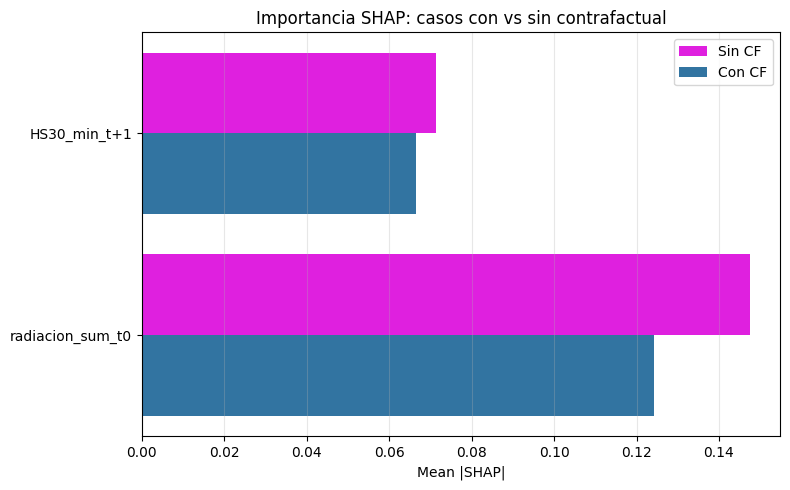

In [32]:
# %%
# =========================
# BARPLOT COMPARATIVO SHAP
# NO APILADO
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

comparison_shap_sorted = comparison_shap.sort_values("Sin_CF", ascending=True).copy()
comparison_shap_sorted = comparison_shap_sorted.reset_index()
comparison_shap_sorted = comparison_shap_sorted.rename(columns={"index": "feature"})

# Pasar a formato largo
comparison_shap_long = comparison_shap_sorted.melt(
    id_vars="feature",
    value_vars=["Sin_CF", "Con_CF"],
    var_name="Grupo",
    value_name="MeanAbsSHAP"
)

# Renombrar para que quede bonito en la leyenda
comparison_shap_long["Grupo"] = comparison_shap_long["Grupo"].map({
    "Sin_CF": "Sin CF",
    "Con_CF": "Con CF"
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison_shap_long,
    x="MeanAbsSHAP",
    y="feature",
    hue="Grupo",
    palette={"Sin CF": "fuchsia", "Con CF": "tab:blue"}
)

plt.title("Importancia SHAP: casos con vs sin contrafactual")
plt.xlabel("Mean |SHAP|")
plt.ylabel("")
plt.grid(True, axis="x", alpha=0.3)
plt.legend(title="")

plt.tight_layout()
plt.savefig("shap_comparacion.png", dpi=300, bbox_inches="tight")
plt.show()

Probabilidad de estrés: 0.9821725034947749
Instancia: 0


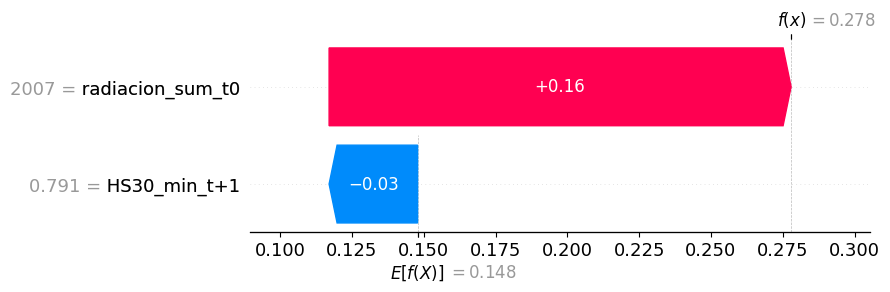

In [ ]:
# =========================
# WATERFALL DE UN CASO SIN CF
# =========================
if len(X_without_cf) > 0:
    idx_local = 0  

    base = explainer.expected_value
    if isinstance(base, (list, np.ndarray)):
        base = np.array(base).flatten()[0]

    shap_val_local = shap_values_without[idx_local]
    prob_case = pipe.predict_proba(X_without_cf.iloc[[idx_local]])[:, 1][0]

    print("Probabilidad de estrés:", prob_case)
    print("Instancia:", X_without_cf.index[idx_local])

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_val_local,
            base_values=base,
            data=X_without_cf.iloc[idx_local].values,
            feature_names=FEATURES
        )
    )
else:
    print("No hay casos sin contrafactual para waterfall.")

Probabilidad de estrés: 0.8903307570354894
Instancia: 4


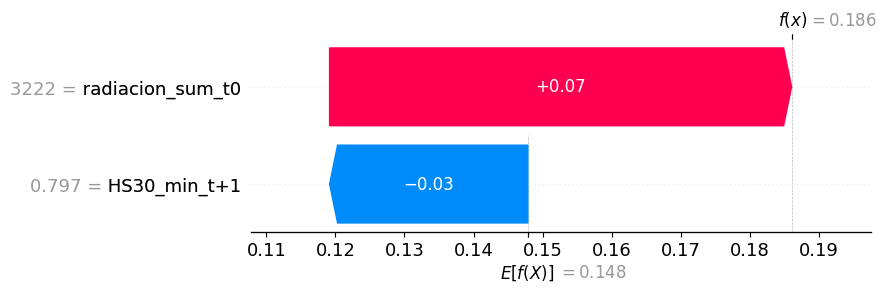

In [ ]:
# %%
# =========================
# WATERFALL DE UN CASO CON CF
# =========================
if len(X_with_cf) > 0:
    idx_local = 0  

    base = explainer.expected_value
    if isinstance(base, (list, np.ndarray)):
        base = np.array(base).flatten()[0]

    shap_val_local = shap_values_with[idx_local]
    prob_case = pipe.predict_proba(X_with_cf.iloc[[idx_local]])[:, 1][0]

    print("Probabilidad de estrés:", prob_case)
    print("Instancia:", X_with_cf.index[idx_local])

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_val_local,
            base_values=base,
            data=X_with_cf.iloc[idx_local].values,
            feature_names=FEATURES
        )
    )
else:
    print("No hay casos con contrafactual para waterfall.")

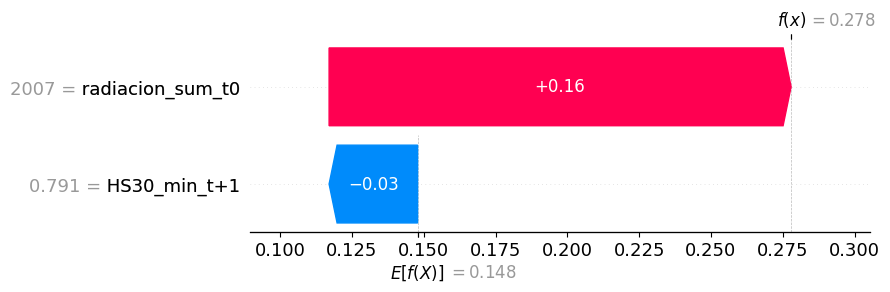

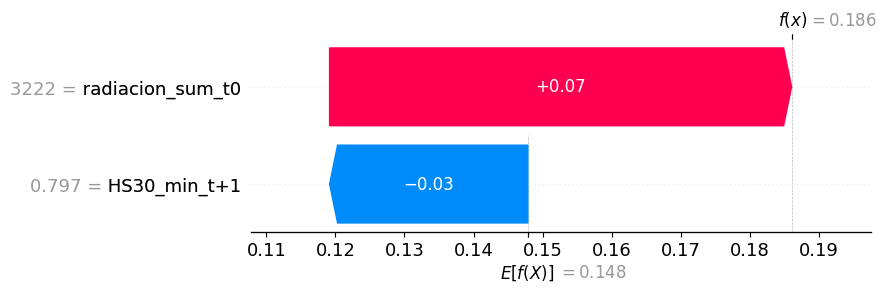

In [31]:
# %%
# Caso sin contrafactual
idx_local = 0

base = explainer.expected_value
if isinstance(base, (list, np.ndarray)):
    base = np.array(base).flatten()[0]

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_without[idx_local],
        base_values=base,
        data=X_without_cf.iloc[idx_local].values,
        feature_names=FEATURES
    )
)

# %%
# Caso con contrafactual
idx_local = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_with[idx_local],
        base_values=base,
        data=X_with_cf.iloc[idx_local].values,
        feature_names=FEATURES
    )
)

In [29]:
# %%
# =========================
# TABLA RESUMEN CASOS SIN CF
# =========================
if len(cases_no_cf_df) > 0 and DATE_COL in cases_no_cf_df.columns:
    display(cases_no_cf_df[[DATE_COL, "pred_prob_stress"]])
else:
    print("No hay instantes sin contrafactual disponibles.")

,instante_t+1,pred_prob_stress
0,2018-09-16,0.982173
1,2018-10-15,0.948143
2,2018-10-21,0.944915
3,2018-10-24,0.820944
5,2018-11-03,0.982173
7,2019-09-13,0.982173
24,2022-09-14,0.980198
25,2022-09-15,0.954450


Análisis de Fasle Positives

In [34]:
# %%
# =========================
# DEFINIR FALSE POSITIVES
# =========================

fp_df = df_all[
    (df_all["Target_Class"] == 0) &
    (df_all["pred_class"] == 1)
].copy()

print("Número de false positives:", len(fp_df))
print(type(fp_df))
display(fp_df.head())

Número de false positives: 23
<class 'pandas.core.frame.DataFrame'>


,instante_t+1,id_nodo,Set_Type,Target_Class,HA_max_t0,HA_mean_t0,HA_min_t0,HS10_max_t0,HS10_mean_t0,HS10_min_t0,...,HS60_max_t+1,HS60_mean_t+1,HS60_min_t+1,TA_max_t+1,TA_mean_t+1,TA_min_t+1,radiacion_max_t+1,radiacion_sum_t+1,pred_prob_stress,pred_class
5,2018-09-09,4,Train_CV,0,87.791900,74.833122,57.339573,0.872395,0.850140,0.834066,...,0.778524,0.776284,0.774343,26.275000,22.737327,19.900000,511.0,2964.0,0.748173,1
22,2018-10-20,4,Train_CV,0,94.106040,82.804914,55.844990,0.841891,0.837451,0.832531,...,0.749065,0.746102,0.743196,22.804167,18.718229,15.604167,477.0,1989.0,0.709041,1
24,2018-10-22,4,Train_CV,0,94.869910,75.639256,57.662228,0.852233,0.845204,0.840670,...,0.748195,0.745801,0.743233,25.600000,19.172569,14.704167,639.0,4052.0,0.500085,1
32,2018-11-02,4,Train_CV,0,67.185070,55.364710,37.633236,0.836905,0.832352,0.825300,...,0.745122,0.740587,0.737818,20.558332,14.291493,10.862500,397.0,2087.0,0.756221,1
41,2019-09-14,4,Train_CV,0,95.978455,85.457734,74.645546,0.816856,0.808299,0.796053,...,0.816575,0.811086,0.807336,25.629166,21.817708,18.758333,544.0,3994.0,0.855943,1


In [35]:
# %%
# =========================
# TRUE NEGATIVES
# =========================

tn_df = df_all[
    (df_all["Target_Class"] == 0) &
    (df_all["pred_class"] == 0)
].copy()

print("Número de true negatives:", len(tn_df))

Número de true negatives: 65


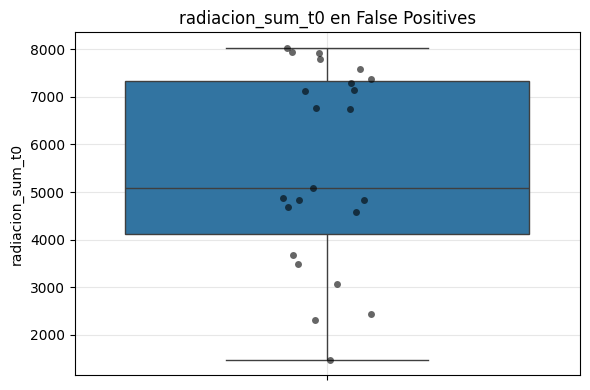

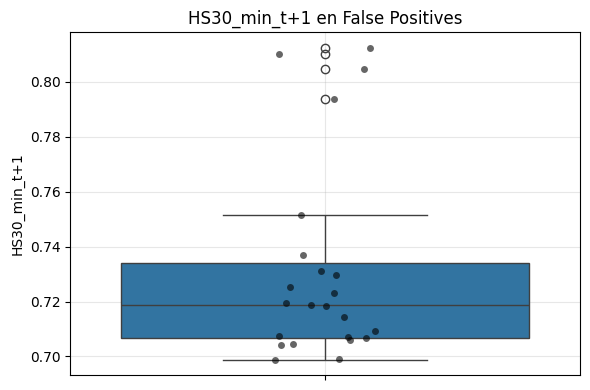

In [36]:
# %%
# =========================
# BOXPLOTS FP
# =========================

import seaborn as sns
import matplotlib.pyplot as plt

vars_plot = ["radiacion_sum_t0", "HS30_min_t+1"]

for var in vars_plot:
    plt.figure(figsize=(6,4))

    sns.boxplot(data=fp_df, y=var)
    sns.stripplot(data=fp_df, y=var, color="black", alpha=0.6)

    plt.title(f"{var} en False Positives")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

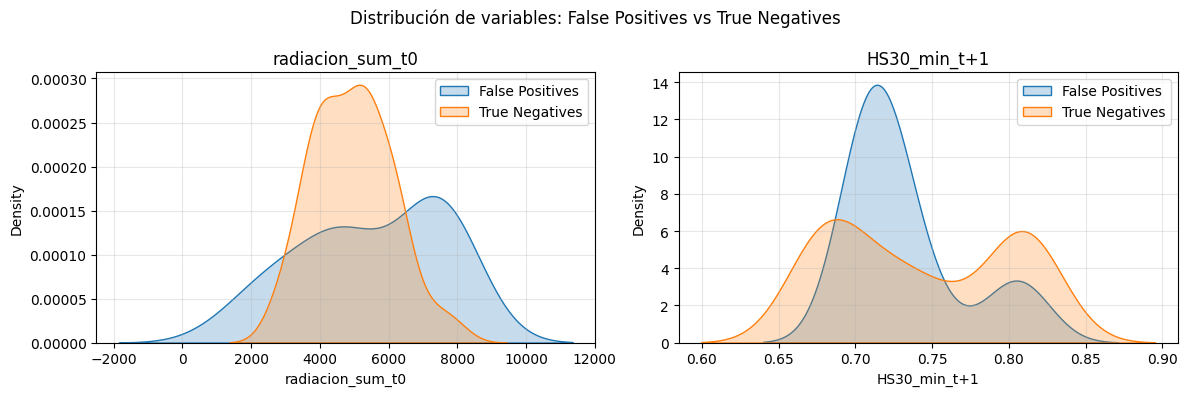

In [42]:
# %%
# =========================
# KDE FP VS TN (JUNTOS)
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, var in enumerate(vars_plot):
    
    ax = axes[i]

    if len(fp_df) > 0:
        sns.kdeplot(fp_df[var], label="False Positives", fill=True, ax=ax)

    if len(tn_df) > 0:
        sns.kdeplot(tn_df[var], label="True Negatives", fill=True, ax=ax)

    ax.set_title(var)
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle("Distribución de variables: False Positives vs True Negatives")

plt.tight_layout()
plt.show()

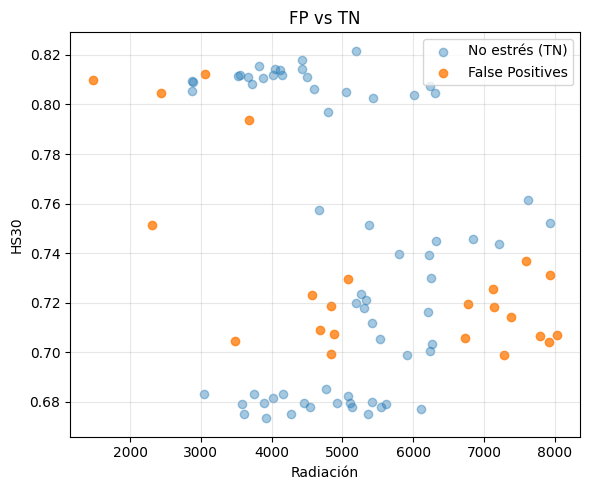

In [38]:
# %%
# =========================
# SCATTER FP VS TN
# =========================

plt.figure(figsize=(6,5))

if len(tn_df) > 0:
    plt.scatter(
        tn_df["radiacion_sum_t0"],
        tn_df["HS30_min_t+1"],
        label="No estrés (TN)",
        alpha=0.4
    )

if len(fp_df) > 0:
    plt.scatter(
        fp_df["radiacion_sum_t0"],
        fp_df["HS30_min_t+1"],
        label="False Positives",
        alpha=0.8
    )

plt.xlabel("Radiación")
plt.ylabel("HS30")
plt.legend()
plt.grid(alpha=0.3)
plt.title("FP vs TN")

plt.tight_layout()
plt.show()

In [39]:
# %%
# =========================
# DICE EN FALSE POSITIVES
# =========================

if len(fp_df) > 0:
    X_fp = fp_df[FEATURES].copy()

    try:
        dice_exp_fp = exp.generate_counterfactuals(
            X_fp,
            total_CFs=1,
            desired_class="opposite",
            features_to_vary=FEATURES_TO_VARY_DICE
        )

        print("Contrafactuales generados para FP")
        display(dice_exp_fp.cf_examples_list[0].final_cfs_df)

    except Exception as e:
        print("Error generando contrafactuales:", e)

else:
    print("No hay false positives para analizar")

100%|██████████| 23/23 [00:00<00:00, 25.11it/s]

Contrafactuales generados para FP


,radiacion_sum_t0,HS30_min_t+1,Target_Class
0,2435.0,0.680746,0


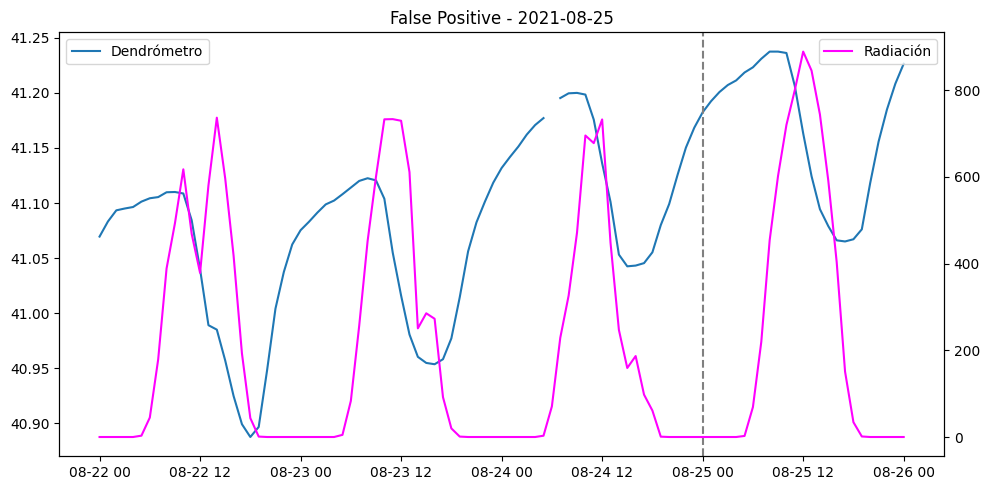

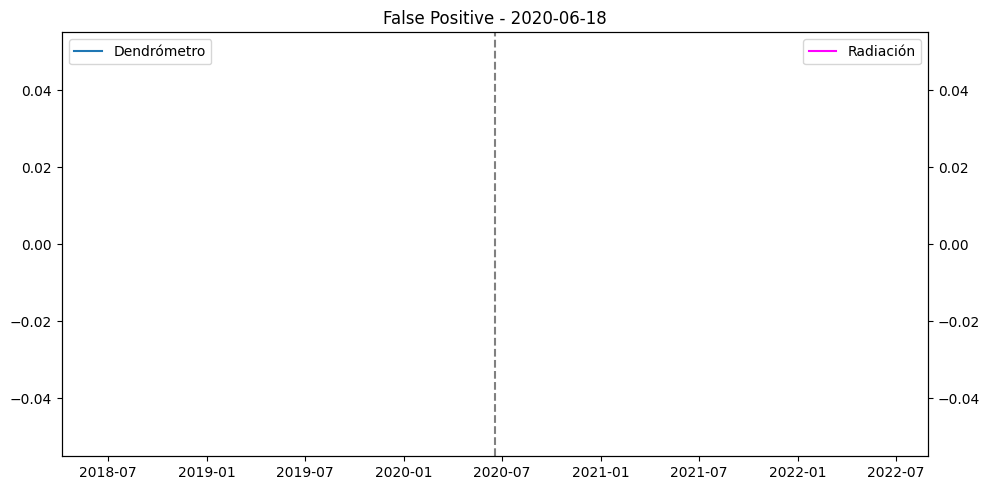

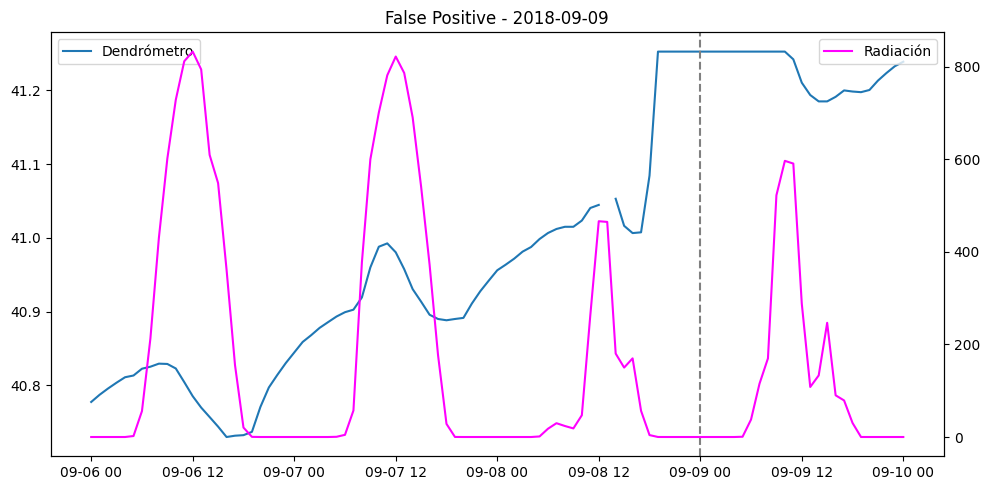

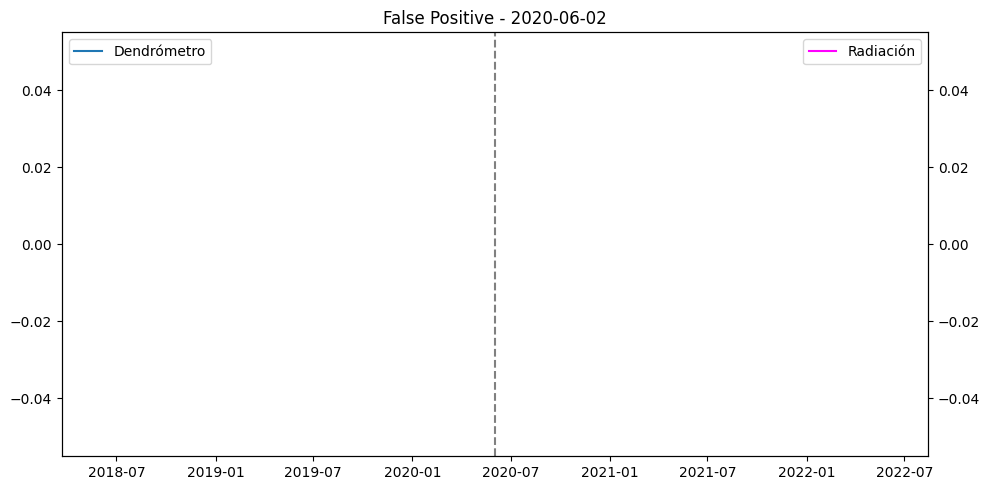

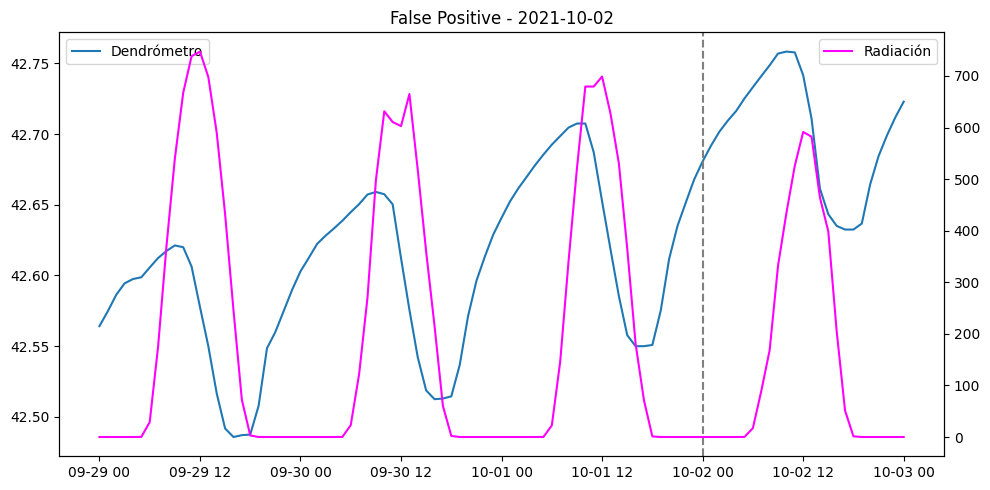

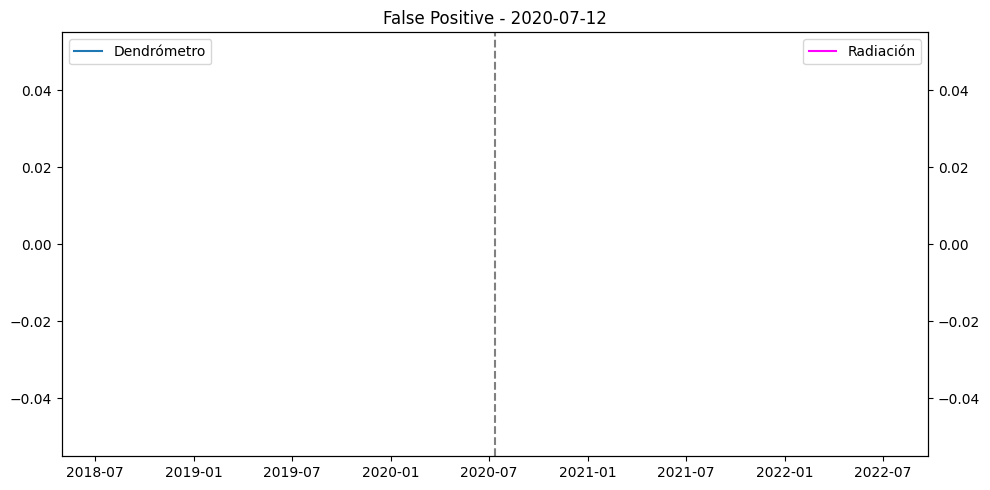

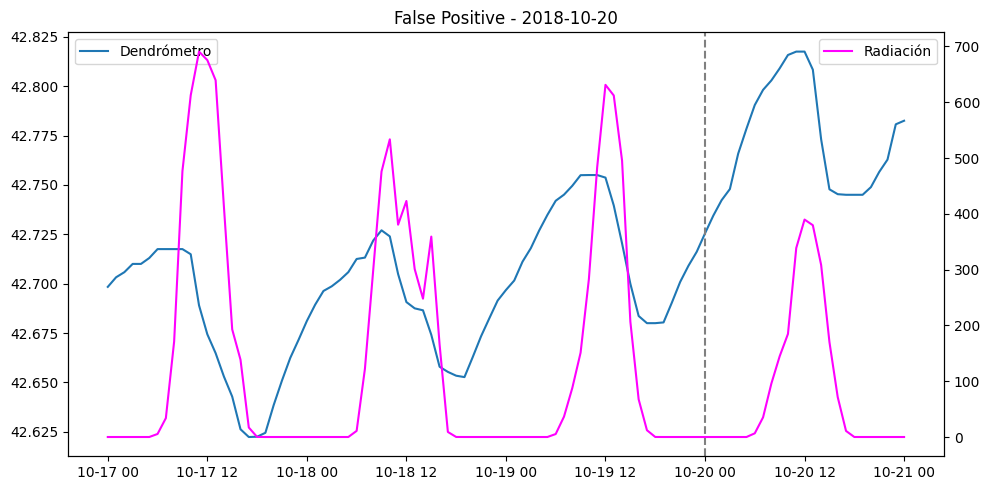

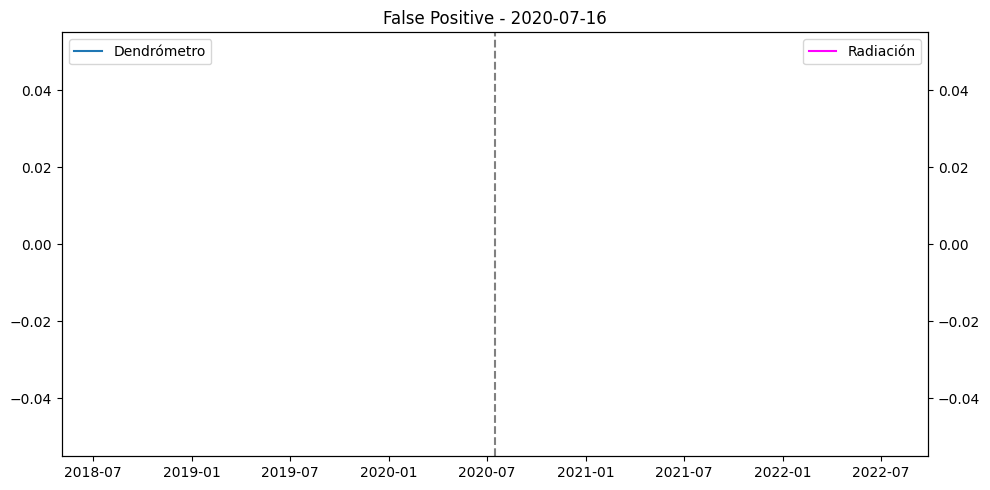

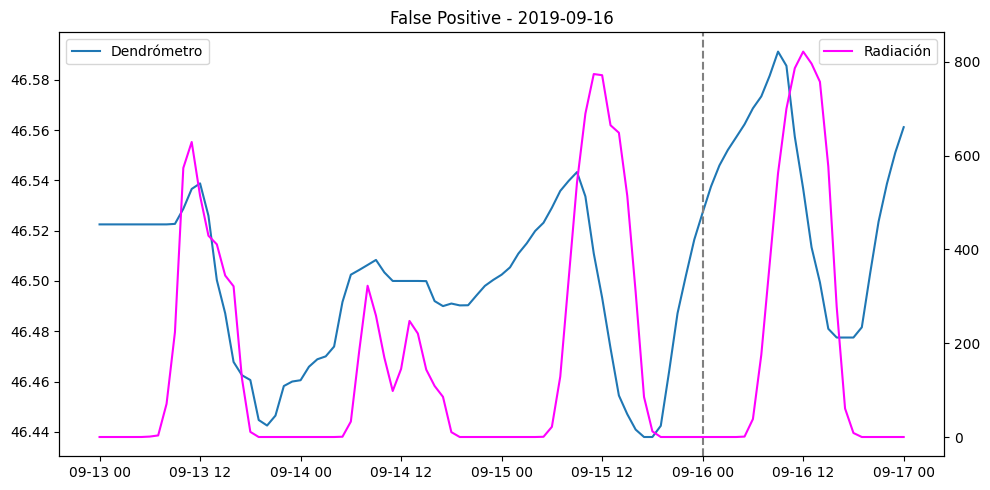

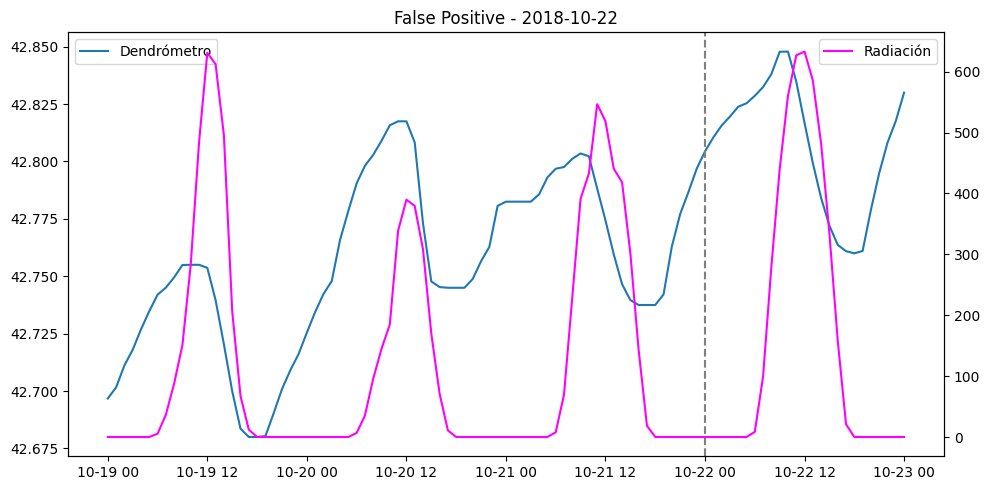

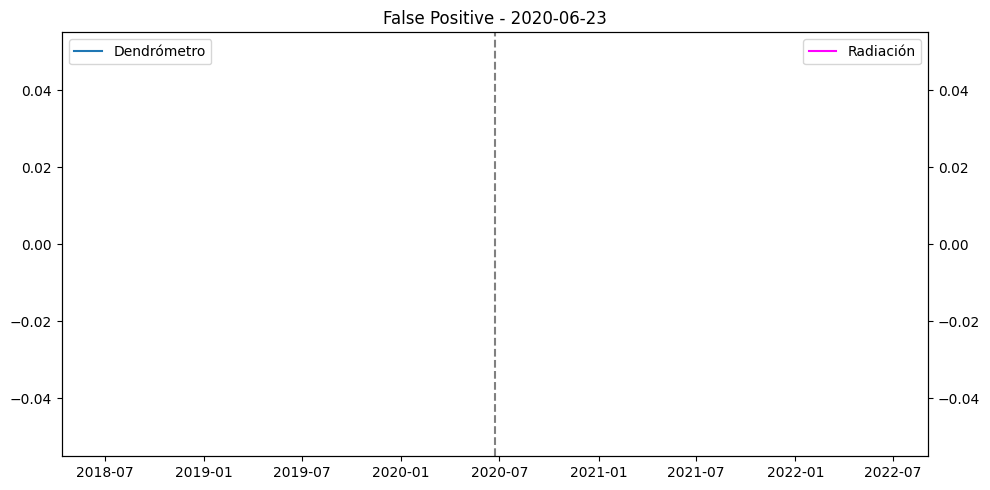

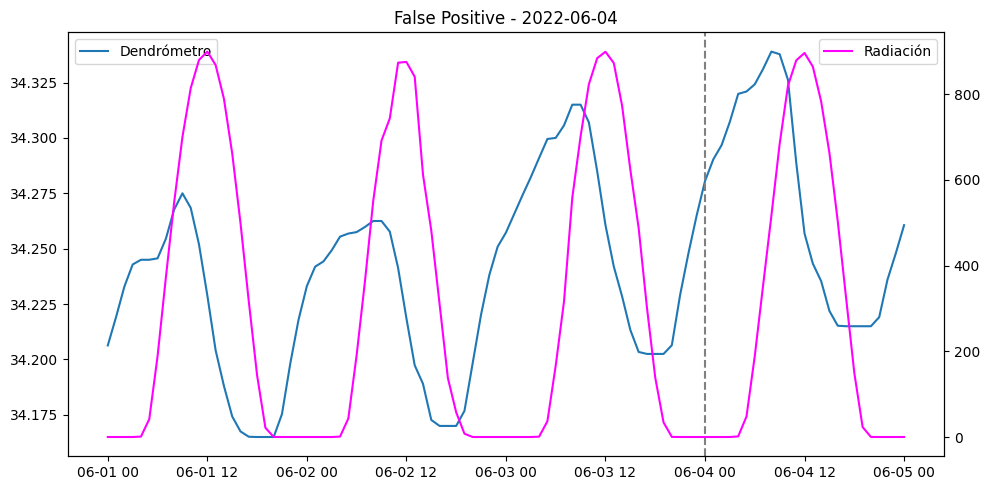

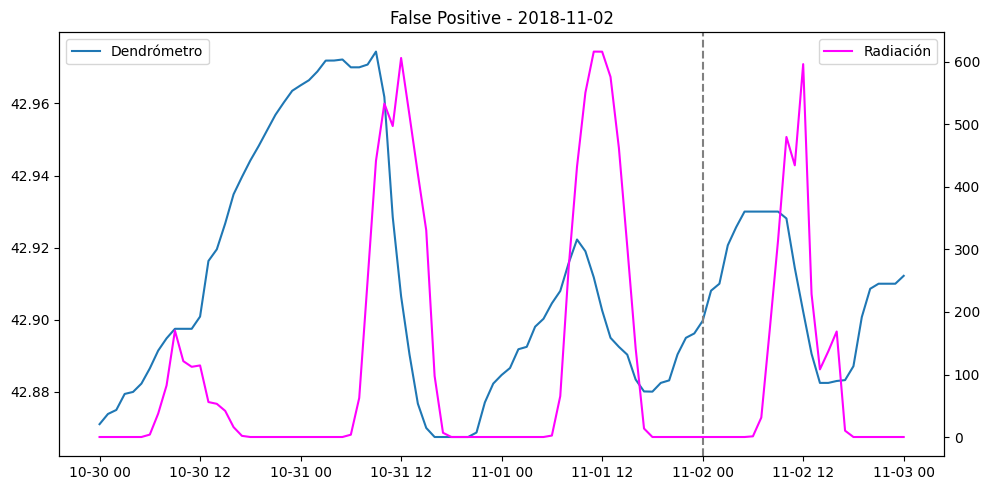

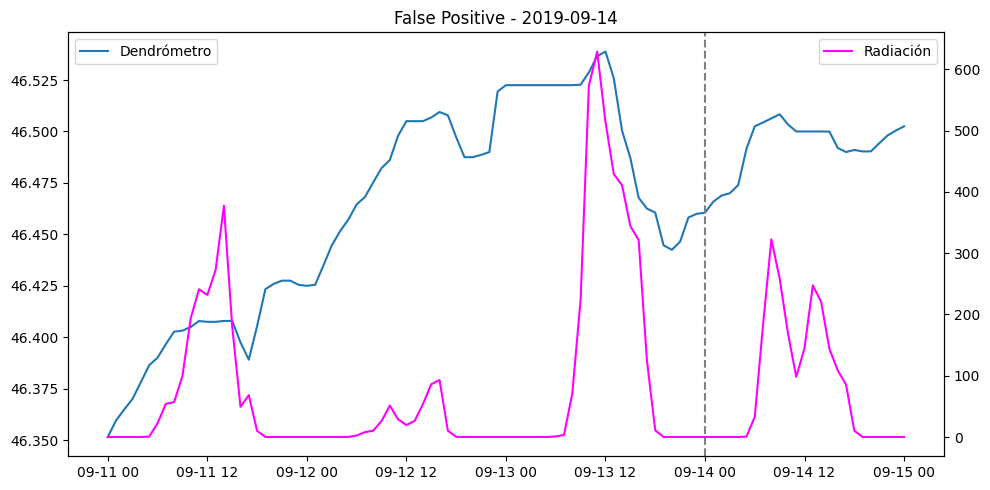

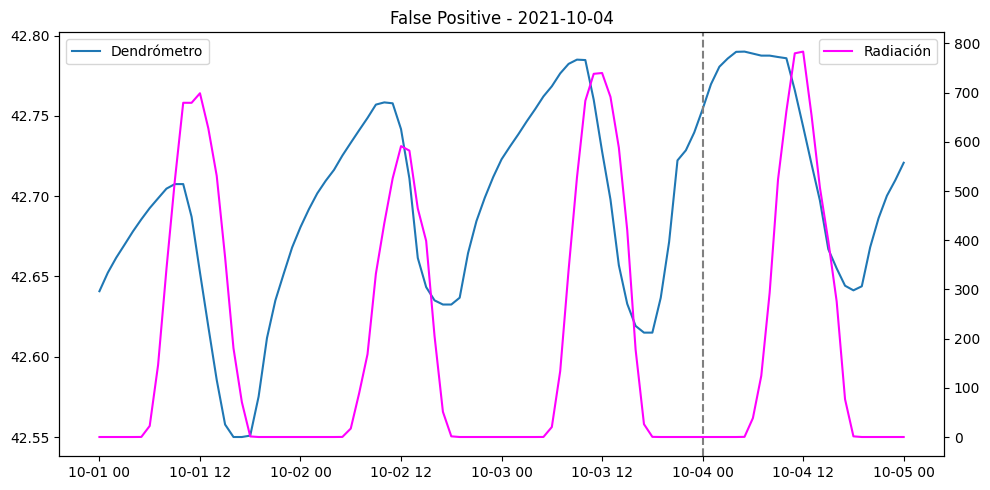

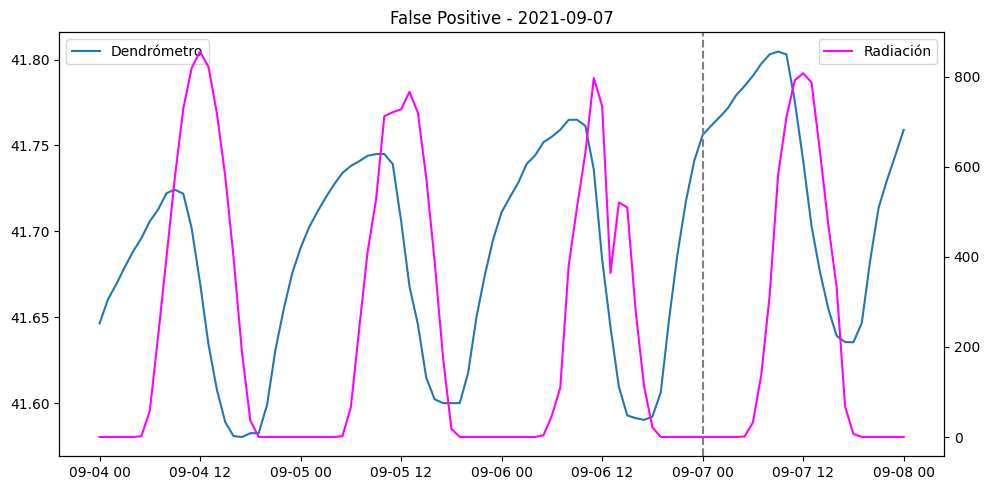

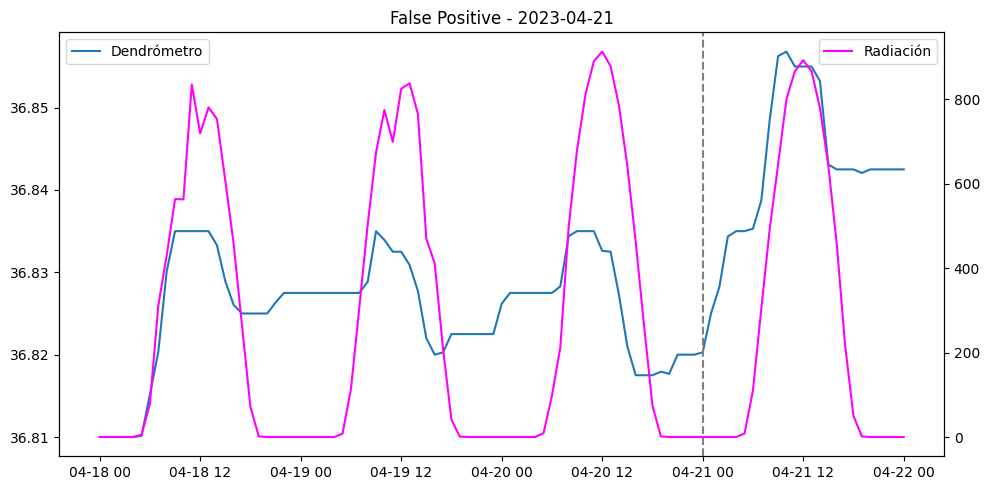

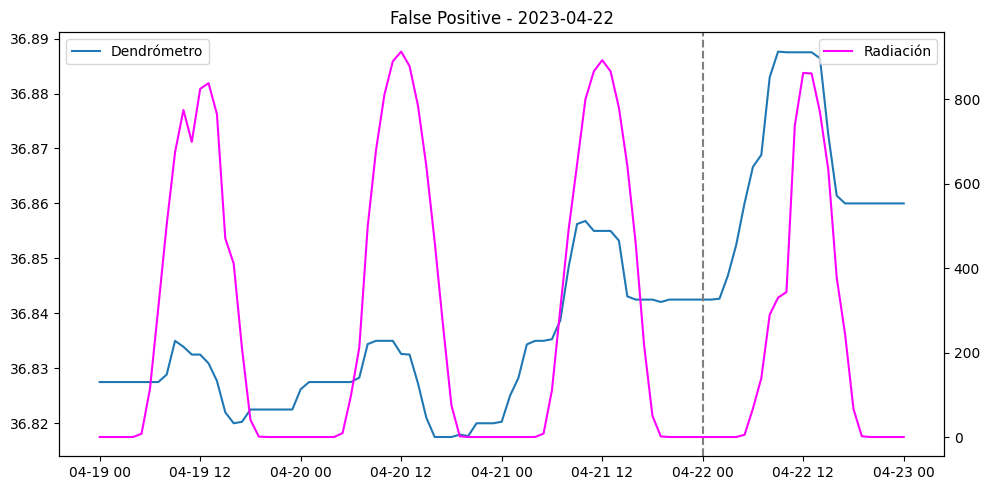

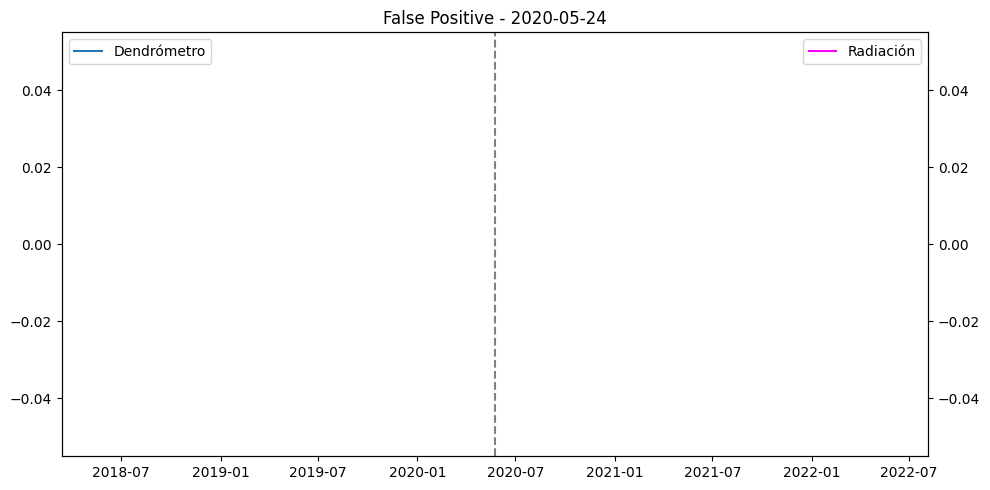

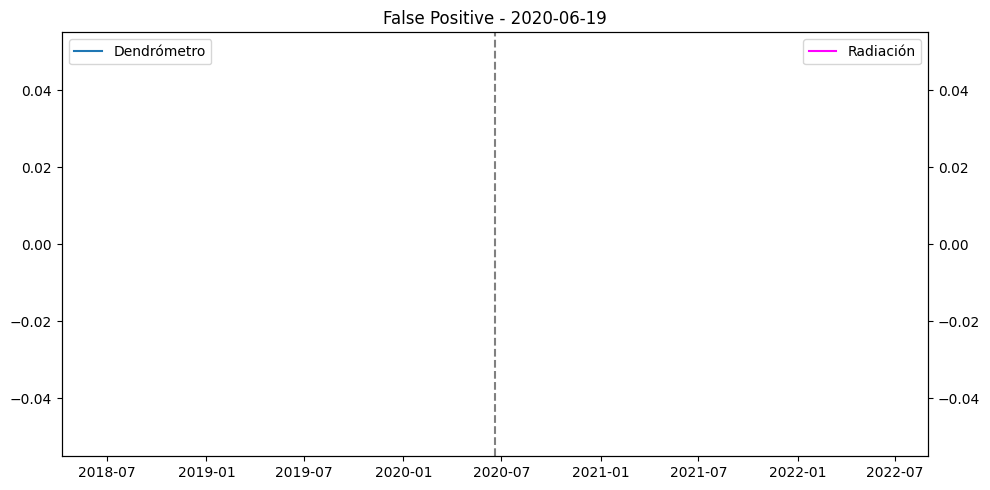

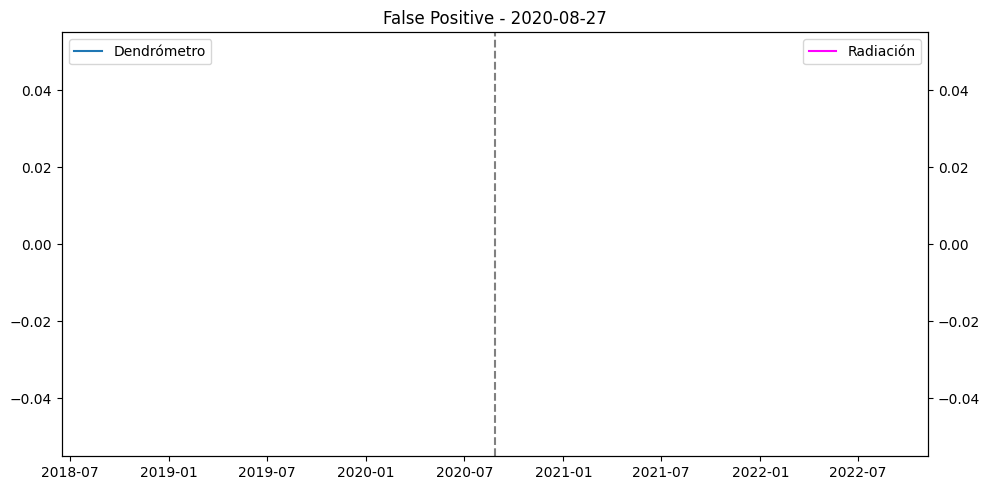

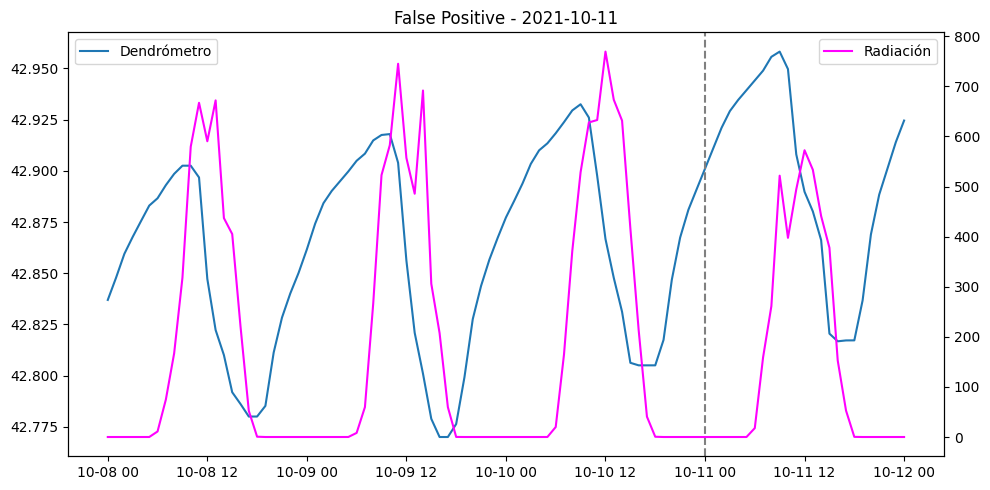

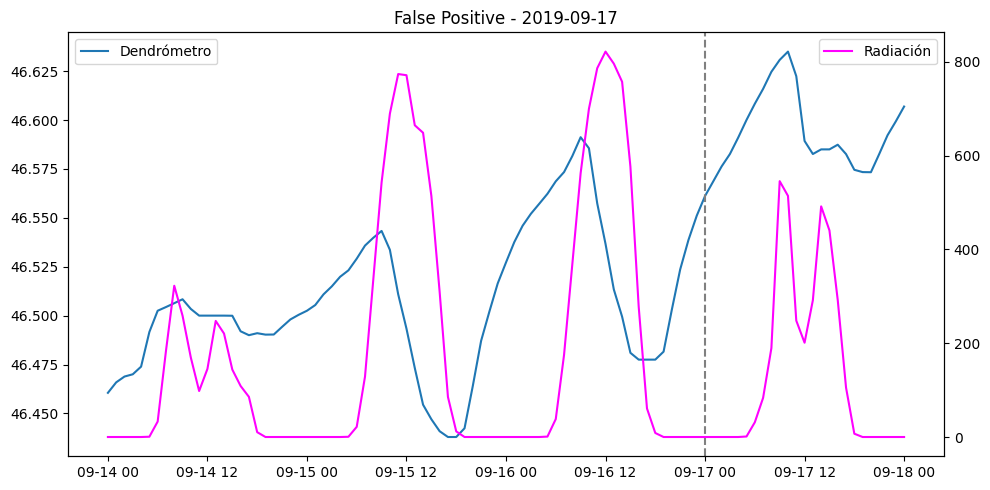

In [41]:
# %%
# =========================
# EVOLUCIÓN TEMPORAL FP
# =========================

if len(fp_df) > 0:

    df_hourly = pd.read_csv("data_hourly_agg.csv")
    df_hourly["instante"] = pd.to_datetime(df_hourly["instante"])

    cases_fp = fp_df[DATE_COL].sample(min(23, len(fp_df)), random_state=42)

    for inst in cases_fp:

        inst = pd.to_datetime(inst)

        start = inst - pd.Timedelta(days=3)
        end = inst + pd.Timedelta(days=1)

        df_case = df_hourly[
            (df_hourly["instante"] >= start) &
            (df_hourly["instante"] <= end)
        ].copy()

        fig, ax1 = plt.subplots(figsize=(10,5))

        ax1.plot(
            df_case["instante"],
            df_case["dendrometro_mean"],
            color="tab:blue",
            label="Dendrómetro"
        )

        ax2 = ax1.twinx()
        ax2.plot(
            df_case["instante"],
            df_case["radiacion_mean"],
            color="fuchsia",
            label="Radiación"
        )

        ax1.axvline(inst, linestyle="--", color="gray")

        ax1.legend(loc="upper left")
        ax2.legend(loc="upper right")

        plt.title(f"False Positive - {inst.date()}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

else:
    print("No hay false positives para graficar")

## Cómo justificar los casos sin contrafactual

- El modelo mantiene la definición operativa de estrés del trabajo.
- DiCE muestra que no todos los casos etiquetados como estrés son corregibles modificando solo `HS30_min_t+1`.
- La ausencia de contrafactual no implica error del algoritmo: indica que, para esos casos, cambiar únicamente la humedad del suelo no basta para revertir la predicción.
- Esto sugiere heterogeneidad dentro de la clase positiva: algunos casos parecen compatibles con un mecanismo hídrico corregible, mientras que otros responden a una dinámica distinta asociada a la comparación entre mínimos diarios y a las condiciones del día previo.
